In [21]:
import gcinfo

gcinfo.list_resources(gcinfo.search_datasets(query='title:"Permanent Residents – Monthly IRCC Updates"')["results"][0])


=== Permanent Residents – Monthly IRCC Updates ===
ID: f7e5498e-0ad8-4417-85c9-9b8aff9b9eda
Org: Immigration, Refugees and Citizenship Canada | Immigration, Réfugiés et Citoyenneté Canada
Notes: People who have been granted permanent resident status in Canada.

Please note that in these datasets, the figures have been suppressed or rounded to prevent the identification of individuals when t...
Citation: Immigration, Refugees and Citizenship Canada. Permanent Residents – Monthly IRCC Updates
  [XLSX    ] Canada - Permanent Residents by Province/Territory and Immigration Category
           https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-PR-ProvImmCat.xlsx
  [XLSX    ] Canada - Permanent Residents by Province/Territory and Immigration Category
           https://www.ircc.canada.ca/opendata-donneesouvertes/data/FR_ODP-PR-ProvImmCat.xlsx
  [CSV     ] [rounded - not for calculations] Canada - Permanent resident by province/territory and immigration category
           https

In [22]:
df = gcinfo.download_xlsx("https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-PR-Citz.xlsx")
df

Using cached file: cache\EN_ODP-PR-Citz.xlsx


,"Canada - Admissions of Permanent Residents by Country of Citizenship, January 2015 - May 2026",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 186,Unnamed: 187,Unnamed: 188,Unnamed: 189,Unnamed: 190,Unnamed: 191,Unnamed: 192,Unnamed: 193,Unnamed: 194,Unnamed: 195
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Country of Citizenship,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Q1,NaN,NaN,NaN,Q2,NaN,NaN,NaN,Q3,...,NaN,2025 Total,Q1,NaN,NaN,NaN,Q2,NaN,NaN,2026 Total
3,NaN,Jan,Feb,Mar,Q1 Total,Apr,May,Jun,Q2 Total,Jul,...,Q4 Total,NaN,Jan,Feb,Mar,Q1 Total,Apr,May,Q2 Total,NaN
4,Afghanistan,90,125,220,435,135,220,195,555,250,...,"2,560","8,215",235,380,430,"1,050",180,830,"1,010","2,055"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,Notes:\n— Please note that all values between ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df["Canada - Admissions of Permanent Residents by Country of Citizenship, January 2015 - May 2026"][4:-7]

4                  Afghanistan
5                      Albania
6                      Algeria
7                      Andorra
8                       Angola
                ...           
215    Virgin Islands, British
216             Western Sahara
217                      Yemen
218                     Zambia
219                   Zimbabwe
Name: Canada - Admissions of Permanent Residents by Country of Citizenship, January 2015 - May 2026, Length: 216, dtype: object

In [24]:
df["Unnamed: 187"][4:-7]

4      8,215
5        485
6      7,600
7         --
8        205
       ...  
215        0
216       --
217      560
218       70
219      570
Name: Unnamed: 187, Length: 216, dtype: object

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

countries = df["Canada - Admissions of Permanent Residents by Country of Citizenship, January 2015 - May 2026"][4:-7]
values = df["Unnamed: 187"][4:-7].apply(lambda x: x.replace(",", "").replace("--", "0")).astype(int)

plot_df = pd.DataFrame({
    "Country": countries.values,
    "Admissions": values.values
})
plot_df = plot_df.sort_values(by="Admissions", ascending=False)
plot_df

,Country,Admissions
81,India,98830
151,Philippines,25230
31,"Cameroon, Federal Republic of",22925
36,"China, People's Republic of",21115
139,Nigeria,16355
...,...,...
194,Tonga,0
200,Tuvalu,0
208,Vanuatu,0
211,"Virgin Islands, British",0


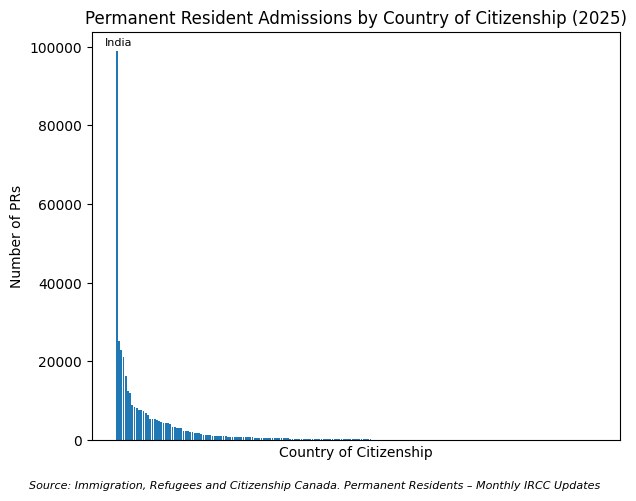

In [42]:
plot_df["Admissions"] = (
    plot_df["Admissions"]
    .replace("--", "0")
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

fig, ax = plt.subplots()
ax.bar(plot_df["Country"], plot_df["Admissions"])

# Label only the largest bar
max_idx = plot_df["Admissions"].idxmax()
max_country = plot_df.loc[max_idx, "Country"]
max_value = plot_df.loc[max_idx, "Admissions"]

ax.annotate(
    max_country,
    xy=(max_country, max_value),
    xytext=(11, 3),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=8
)

ax.set_title("Permanent Resident Admissions by Country of Citizenship (2025)")
ax.set_xlabel("Country of Citizenship")
ax.set_ylabel("Number of PRs")

# Hide all country tick labels
ax.set_xticks([])
ax.set_xticklabels([])

plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5, -0.03,
    "Source: Immigration, Refugees and Citizenship Canada. Permanent Residents – Monthly IRCC Updates",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()